In [10]:
pip install numpy pandas nltk scikit-learn matplotlib seaborn sparse


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: python.exe -m pip install --upgrade pip


In [9]:
from scipy import sparse
import seaborn as sns
import numpy as np
import pandas as pd
import re
from nltk.corpus import stopwords
from nltk.stem.porter import PorterStemmer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import nltk
nltk.download('stopwords')


[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\susha\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [86]:
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("kazanova/sentiment140")

#print("Path to dataset files:", path)

In [11]:
df = pd.read_csv(r"C:\Users\susha\Downloads\archive\training1600000.CSV", encoding="ISO-8859-1")
df

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew
...,...,...,...,...,...,...
1599994,4,2193601966,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,AmandaMarie1028,Just woke up. Having no school is the best fee...
1599995,4,2193601969,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,TheWDBoards,TheWDB.com - Very cool to hear old Walt interv...
1599996,4,2193601991,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,bpbabe,Are you ready for your MoJo Makeover? Ask me f...
1599997,4,2193602064,Tue Jun 16 08:40:49 PDT 2009,NO_QUERY,tinydiamondz,Happy 38th Birthday to my boo of alll time!!! ...


In [12]:
df.head()

,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer. You shoulda got David Carr of Third Day to do it. ;D"
0,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
1,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
2,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
3,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."
4,0,1467811372,Mon Apr 06 22:20:00 PDT 2009,NO_QUERY,joy_wolf,@Kwesidei not the whole crew


In [13]:
column_names = ['target', 'id', 'date', 'flag', 'user', 'text']
twitter_data = pd.read_csv(r"C:\Users\susha\Downloads\archive\training1600000.CSV",names= column_names , encoding ='ISO-8859-1')
twitter_data.head()

,target,id,date,flag,user,text
0,0,1467810369,Mon Apr 06 22:19:45 PDT 2009,NO_QUERY,_TheSpecialOne_,"@switchfoot http://twitpic.com/2y1zl - Awww, t..."
1,0,1467810672,Mon Apr 06 22:19:49 PDT 2009,NO_QUERY,scotthamilton,is upset that he can't update his Facebook by ...
2,0,1467810917,Mon Apr 06 22:19:53 PDT 2009,NO_QUERY,mattycus,@Kenichan I dived many times for the ball. Man...
3,0,1467811184,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,ElleCTF,my whole body feels itchy and like its on fire
4,0,1467811193,Mon Apr 06 22:19:57 PDT 2009,NO_QUERY,Karoli,"@nationwideclass no, it's not behaving at all...."


In [14]:
twitter_data.info

<bound method DataFrame.info of          target          id                          date      flag  \
0             0  1467810369  Mon Apr 06 22:19:45 PDT 2009  NO_QUERY   
1             0  1467810672  Mon Apr 06 22:19:49 PDT 2009  NO_QUERY   
2             0  1467810917  Mon Apr 06 22:19:53 PDT 2009  NO_QUERY   
3             0  1467811184  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
4             0  1467811193  Mon Apr 06 22:19:57 PDT 2009  NO_QUERY   
...         ...         ...                           ...       ...   
1599995       4  2193601966  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599996       4  2193601969  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599997       4  2193601991  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599998       4  2193602064  Tue Jun 16 08:40:49 PDT 2009  NO_QUERY   
1599999       4  2193602129  Tue Jun 16 08:40:50 PDT 2009  NO_QUERY   

                    user                                               text  
0        _TheSpecialOne_  @switchfoot

In [15]:
print(twitter_data['text'][0])

@switchfoot http://twitpic.com/2y1zl - Awww, that's a bummer.  You shoulda got David Carr of Third Day to do it. ;D


In [16]:
twitter_data.isnull().sum()


target    0
id        0
date      0
flag      0
user      0
text      0
dtype: int64

In [10]:
import pandas as pd

# Load your dataset
#df = pd.read_csv(r"C:\Users\susha\Downloads\archive\training1600000.CSV", encoding="ISO-8859-1")
# Filter rows for each value
df_0 = twitter_data[twitter_data['target'] == 0].sample(n=100000, random_state=42)
df_4 = twitter_data[twitter_data['target'] == 4].sample(n=100000, random_state=42)

# Combine both
df = pd.concat([df_0, df_4])

# Save to new CSV file
df.to_csv("extracted_0_4_rows.csv", index=False)

print("✅ 1 lakh rows of each (0 and 4) extracted and saved to 'extracted_0_4_rows.csv'")

✅ 1 lakh rows of each (0 and 4) extracted and saved to 'extracted_0_4_rows.csv'


In [17]:
twitter_data=pd.read_csv('extracted_0_4_rows.csv')

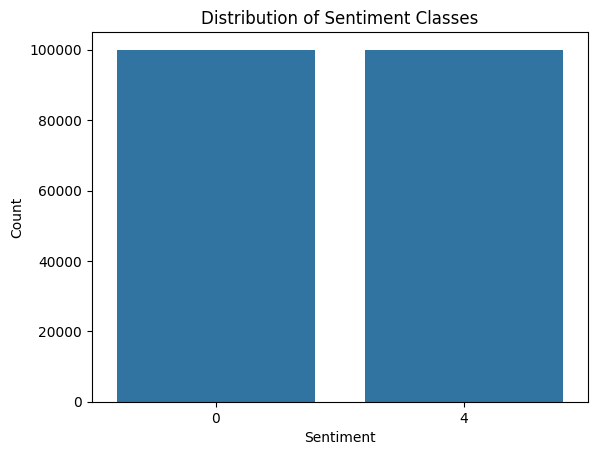

In [18]:
import seaborn as sns
sns.countplot(x=twitter_data['target'])
plt.title("Distribution of Sentiment Classes")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [19]:
twitter_data.replace({'target':{4:1}}, inplace= True)
twitter_data['target'].value_counts()


target
0    100000
1    100000
Name: count, dtype: int64

### 0 = negative and 1= positive

# Steming re duce word to root word

In [20]:
port_stem = PorterStemmer()
def stemming(content):
    # remove non-alphabet characters
    stemmed_content = re.sub('[^a-zA-Z]',' ',content)
    # lowercase
    stemmed_content = stemmed_content.lower()
    # tokenize
    stemmed_content = stemmed_content.split()
    # remove stopwords and apply stemming
    stemmed_content = [port_stem.stem(word) for word in stemmed_content if word not in stopwords.words('english')]
    # join back into sentence
    stemmed_content = ' '.join(stemmed_content)
    return stemmed_content


In [21]:
twitter_data['stemmed_content']=twitter_data['text'].apply(stemming)

# split data for model training and testing

In [22]:
x=twitter_data['text']
y=twitter_data['target']

In [23]:
x_train,x_test,y_train,y_test= train_test_split(x,y, test_size= 0.2, stratify=y, random_state=2)

In [24]:
y1=x_test

In [25]:
# converting the textual data to numerical data

vectorizer = TfidfVectorizer()
x_train = vectorizer.fit_transform(x_train)
x_test = vectorizer.transform(x_test)

In [26]:

# Save
sparse.save_npz("X_train.npz", x_train)
sparse.save_npz("X_test.npz", x_test)

In [27]:
# Load later
from scipy import sparse
X_train = sparse.load_npz("X_train.npz")
X_test = sparse.load_npz("X_test.npz")

# Training logistic regression model for sentimental analysis

In [28]:
model= LogisticRegression(max_iter=1000)

In [29]:
model.fit(x_train,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [30]:
1 # accuracy score on the training data
X_train_prediction = model.predict(x_train)
training_data_accuracy = accuracy_score(y_train, X_train_prediction)

In [31]:
print('Accuracy score on the training data :',training_data_accuracy)

Accuracy score on the training data : 0.8326625


In [32]:
# accuracy score on the test data

X_test_prediction = model.predict (X_test)
test_data_accuracy = accuracy_score(y_test, X_test_prediction)

In [33]:
print('Accuracy score on the training data :', test_data_accuracy)

Accuracy score on the training data : 0.78825


In [34]:
import pickle
filename = 'trained model.sav'
pickle.dump(model, open(filename, 'wb'))

In [35]:
X_test_prediction

array([0, 1, 0, ..., 1, 1, 1], shape=(40000,))

In [36]:
pred=pd.DataFrame({'text': y1,'sentiment':X_test_prediction})
pred

,text,sentiment
69596,@LeanneJLewis when you cant find what you want...,0
29754,About to give up,1
76046,@liamholmes sun wasn't out all day here either...,0
163369,@Mayerinated happy birthday! Hope you have a g...,1
164882,is very happily hungover. thank you everyone w...,1
...,...,...
151677,at school! hope today goes well!!,0
158398,@yasexy and my last!! I'm un following! Lol H...,1
132922,@serendipitousy Your gut will thank you with N...,1
121096,@kathyIreland super stressful day &amp; can't ...,1


# testing on real life data

In [58]:
j=['you are bad']

In [59]:
# converting the textual data to numerical data

x_train = vectorizer.transform(j)
#x_test = vectorizer.transform(x_test)

In [60]:
X_test_prediction = model.predict(x_train)
X_test_prediction

array([0])